In [162]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import seaborn as sns
from pandas import DataFrame

import matplotlib_style
from helpers import rename_patient

In [189]:
# Paths
# on server:
# from config import PATHS
# in_path = PATHS.per_model_comparison_table.pickle  # on server
# out_path = ...

# local:
in_path = Path('~/thesis_files/statistical_results/.per_model.pkl').expanduser()
out_path = Path('~/Developer/MastersThesis/src/figures/model_eval_boxplots.pdf').expanduser()

In [41]:
per_model = pd.read_pickle(in_path)
# per_model

In [45]:
t: DataFrame = per_model.copy()

# Abbreviate patients
idx_df = t.index.to_frame(index=False)
idx_df['patient'] = idx_df['patient'].map(rename_patient)
t.index = pd.MultiIndex.from_frame(idx_df)

t = t.drop(columns=['best_threshold', 'p_hanley_mcneil', 'precision', 'recall'], level=0)

t['rel_tifw'] = 1 - t['rel_tifw']
t = t.rename(columns={'rel_tifw': 'eb_specificity'})

t

metric           eb_specificity           rel_szrs_pred            \
split                     train      test         train      test   
patient model                                                       
C01     CNN            0.849047  0.592619      0.794118  0.541667   
        ensemble       0.631890  0.505280      0.852941  0.500000   
C02     CNN            0.803368  0.669656      0.967742  0.863636   
        ensemble       0.676799  0.602577      0.838710  0.636364   
C03     CNN            0.857629  0.736736      0.945946  0.846154   
        ensemble       0.782887  0.714592      0.837838  0.961538   
U01     CNN            0.773528  0.834952      0.880342  0.794872   
        ensemble       0.733097  0.760820      0.803419  0.782051   
U03     CNN            0.892815  0.626973      0.852941  0.666667   
        ensemble       0.813572  0.573076      0.735294  0.444444   
U04     CNN            0.730922  0.527734      0.783784  0.560000   
        ensemble       0.569273  0.399240      0.729730  0.400000   
U05     CNN            0.934589  0.782437      0.800000  0.857143   
        ensemble       0.828154  0.810361      0.775000  0.785714   
U07     CNN            0.965514  0.816154      1.000000  0.666667   
        ensemble       0.717681  0.542339      0.857143  0.833333   
U12     CNN            0.927835  0.605181      0.777778  0.666667   
        ensemble       0.579669  0.517852      0.833333  0.750000   
U15     CNN            0.952573  0.654722      0.769231  0.700000   
        ensemble       0.684009  0.586062      0.846154  0.600000   
U16     CNN            0.869041  0.649429      1.000000  0.625000   
        ensemble       0.831230  0.784020      0.750000  0.750000   
U17     CNN            0.843273  0.641021      0.833333  0.777778   
        ensemble       0.654481  0.694153      0.833333  0.777778   

metric           event_based_f1             roc_auc            
split                     train      test     train      test  
patient model                                                  
C01     CNN            0.820664  0.565998  0.884805  0.610688  
        ensemble       0.725961  0.502626  0.797698  0.592680  
C02     CNN            0.877928  0.754376  0.893222  0.796782  
        ensemble       0.749106  0.619009  0.770124  0.660440  
C03     CNN            0.899625  0.787663  0.920368  0.853174  
        ensemble       0.809431  0.819874  0.859295  0.854908  
U01     CNN            0.823486  0.814419  0.863207  0.817384  
        ensemble       0.766649  0.771290  0.804567  0.789480  
U03     CNN            0.872423  0.646211  0.895318  0.569616  
        ensemble       0.772455  0.500630  0.756510  0.501869  
U04     CNN            0.756430  0.543388  0.782933  0.533533  
        ensemble       0.639591  0.399620  0.655552  0.379864  
U05     CNN            0.862073  0.818088  0.914183  0.813468  
        ensemble       0.800696  0.797847  0.801858  0.762792  
U07     CNN            0.982454  0.733875  0.916109  0.689317  
        ensemble       0.781237  0.657059  0.730595  0.687059  
U12     CNN            0.846206  0.634438  0.927067  0.613660  
        ensemble       0.683732  0.612672  0.725413  0.664865  
U15     CNN            0.851141  0.676604  0.879319  0.604727  
        ensemble       0.756490  0.592949  0.757394  0.577697  
U16     CNN            0.929932  0.636981  0.969105  0.612075  
        ensemble       0.788529  0.766633  0.746023  0.613146  
U17     CNN            0.838274  0.702808  0.898036  0.690451  
        ensemble       0.733157  0.733590  0.754901  0.787532

In [109]:
# Move the model from index to columns

s = t.copy()
s = s.unstack(level='model')  # Get just the patients as rows
s = s.reorder_levels(['metric', 'model', 'split'], axis='columns')

metric_order = s.columns.get_level_values('metric').unique().tolist()
model_order = ['CNN', 'ensemble']
split_order = ['train', 'test']

# apply ordered categories to the relevant levels
s.columns = (
    s.columns.set_levels(
        pd.CategoricalIndex(s.columns.levels[s.columns.names.index('metric')],
                            categories=metric_order, ordered=True),
        level='metric'
    ).set_levels(
        pd.CategoricalIndex(s.columns.levels[s.columns.names.index('model')],
                            categories=model_order, ordered=True),
        level='model'
    ).set_levels(
        pd.CategoricalIndex(s.columns.levels[s.columns.names.index('split')],
                            categories=split_order, ordered=True),
        level='split'
    )
)

s = s.sort_index(axis='columns')
s

metric  eb_specificity                               rel_szrs_pred            \
model              CNN            ensemble                     CNN             
split            train      test     train      test         train      test   
patient                                                                        
C01           0.849047  0.592619  0.631890  0.505280      0.794118  0.541667   
C02           0.803368  0.669656  0.676799  0.602577      0.967742  0.863636   
C03           0.857629  0.736736  0.782887  0.714592      0.945946  0.846154   
U01           0.773528  0.834952  0.733097  0.760820      0.880342  0.794872   
U03           0.892815  0.626973  0.813572  0.573076      0.852941  0.666667   
U04           0.730922  0.527734  0.569273  0.399240      0.783784  0.560000   
U05           0.934589  0.782437  0.828154  0.810361      0.800000  0.857143   
U07           0.965514  0.816154  0.717681  0.542339      1.000000  0.666667   
U12           0.927835  0.605181  0.579669  0.517852      0.777778  0.666667   
U15           0.952573  0.654722  0.684009  0.586062      0.769231  0.700000   
U16           0.869041  0.649429  0.831230  0.784020      1.000000  0.625000   
U17           0.843273  0.641021  0.654481  0.694153      0.833333  0.777778   

metric                      event_based_f1                                \
model    ensemble                      CNN            ensemble             
split       train      test          train      test     train      test   
patient                                                                    
C01      0.852941  0.500000       0.820664  0.565998  0.725961  0.502626   
C02      0.838710  0.636364       0.877928  0.754376  0.749106  0.619009   
C03      0.837838  0.961538       0.899625  0.787663  0.809431  0.819874   
U01      0.803419  0.782051       0.823486  0.814419  0.766649  0.771290   
U03      0.735294  0.444444       0.872423  0.646211  0.772455  0.500630   
U04      0.729730  0.400000       0.756430  0.543388  0.639591  0.399620   
U05      0.775000  0.785714       0.862073  0.818088  0.800696  0.797847   
U07      0.857143  0.833333       0.982454  0.733875  0.781237  0.657059   
U12      0.833333  0.750000       0.846206  0.634438  0.683732  0.612672   
U15      0.846154  0.600000       0.851141  0.676604  0.756490  0.592949   
U16      0.750000  0.750000       0.929932  0.636981  0.788529  0.766633   
U17      0.833333  0.777778       0.838274  0.702808  0.733157  0.733590   

metric    roc_auc                                
model         CNN            ensemble            
split       train      test     train      test  
patient                                          
C01      0.884805  0.610688  0.797698  0.592680  
C02      0.893222  0.796782  0.770124  0.660440  
C03      0.920368  0.853174  0.859295  0.854908  
U01      0.863207  0.817384  0.804567  0.789480  
U03      0.895318  0.569616  0.756510  0.501869  
U04      0.782933  0.533533  0.655552  0.379864  
U05      0.914183  0.813468  0.801858  0.762792  
U07      0.916109  0.689317  0.730595  0.687059  
U12      0.927067  0.613660  0.725413  0.664865  
U15      0.879319  0.604727  0.757394  0.577697  
U16      0.969105  0.612075  0.746023  0.613146  
U17      0.898036  0.690451  0.754901  0.787532

In [134]:
r = s.copy()
r = r.rename(
    columns={
        'eb_specificity': 'EB Specificity',
        'rel_szrs_pred': 'EB Sensitivity',
        'event_based_f1': 'EB Score',
        'roc_auc': 'ROC AUC',
        'train': 'Train',
        'test': 'Test',
        'ensemble': 'Ensemble'
    }
)
r

metric  EB Specificity                               EB Sensitivity            \
model              CNN            Ensemble                      CNN             
split            Train      Test     Train      Test          Train      Test   
patient                                                                         
C01           0.849047  0.592619  0.631890  0.505280       0.794118  0.541667   
C02           0.803368  0.669656  0.676799  0.602577       0.967742  0.863636   
C03           0.857629  0.736736  0.782887  0.714592       0.945946  0.846154   
U01           0.773528  0.834952  0.733097  0.760820       0.880342  0.794872   
U03           0.892815  0.626973  0.813572  0.573076       0.852941  0.666667   
U04           0.730922  0.527734  0.569273  0.399240       0.783784  0.560000   
U05           0.934589  0.782437  0.828154  0.810361       0.800000  0.857143   
U07           0.965514  0.816154  0.717681  0.542339       1.000000  0.666667   
U12           0.927835  0.605181  0.579669  0.517852       0.777778  0.666667   
U15           0.952573  0.654722  0.684009  0.586062       0.769231  0.700000   
U16           0.869041  0.649429  0.831230  0.784020       1.000000  0.625000   
U17           0.843273  0.641021  0.654481  0.694153       0.833333  0.777778   

metric                       EB Score                                 ROC AUC  \
model    Ensemble                 CNN            Ensemble                 CNN   
split       Train      Test     Train      Test     Train      Test     Train   
patient                                                                         
C01      0.852941  0.500000  0.820664  0.565998  0.725961  0.502626  0.884805   
C02      0.838710  0.636364  0.877928  0.754376  0.749106  0.619009  0.893222   
C03      0.837838  0.961538  0.899625  0.787663  0.809431  0.819874  0.920368   
U01      0.803419  0.782051  0.823486  0.814419  0.766649  0.771290  0.863207   
U03      0.735294  0.444444  0.872423  0.646211  0.772455  0.500630  0.895318   
U04      0.729730  0.400000  0.756430  0.543388  0.639591  0.399620  0.782933   
U05      0.775000  0.785714  0.862073  0.818088  0.800696  0.797847  0.914183   
U07      0.857143  0.833333  0.982454  0.733875  0.781237  0.657059  0.916109   
U12      0.833333  0.750000  0.846206  0.634438  0.683732  0.612672  0.927067   
U15      0.846154  0.600000  0.851141  0.676604  0.756490  0.592949  0.879319   
U16      0.750000  0.750000  0.929932  0.636981  0.788529  0.766633  0.969105   
U17      0.833333  0.777778  0.838274  0.702808  0.733157  0.733590  0.898036   

metric                                 
model              Ensemble            
split        Test     Train      Test  
patient                                
C01      0.610688  0.797698  0.592680  
C02      0.796782  0.770124  0.660440  
C03      0.853174  0.859295  0.854908  
U01      0.817384  0.804567  0.789480  
U03      0.569616  0.756510  0.501869  
U04      0.533533  0.655552  0.379864  
U05      0.813468  0.801858  0.762792  
U07      0.689317  0.730595  0.687059  
U12      0.613660  0.725413  0.664865  
U15      0.604727  0.757394  0.577697  
U16      0.612075  0.746023  0.613146  
U17      0.690451  0.754901  0.787532

In [187]:
f = r.copy()
f *= 100 # Make values percentages
f = (f
    .stack(["metric", "model", "split"], future_stack=True)
    .reset_index(name="value")
)
f['Model & Partition'] = f['model'].astype(str) + ' ' + f['split'].astype(str)
f

,patient,metric,model,split,value,Model & Partition
0,C01,EB Specificity,CNN,Train,84.904749,CNN Train
1,C01,EB Specificity,CNN,Test,59.261907,CNN Test
2,C01,EB Specificity,Ensemble,Train,63.188951,Ensemble Train
3,C01,EB Specificity,Ensemble,Test,50.527995,Ensemble Test
4,C01,EB Sensitivity,CNN,Train,79.411765,CNN Train
...,...,...,...,...,...,...
187,U17,EB Score,Ensemble,Test,73.358998,Ensemble Test
188,U17,ROC AUC,CNN,Train,89.803552,CNN Train
189,U17,ROC AUC,CNN,Test,69.045071,CNN Test
190,U17,ROC AUC,Ensemble,Train,75.490138,Ensemble Train


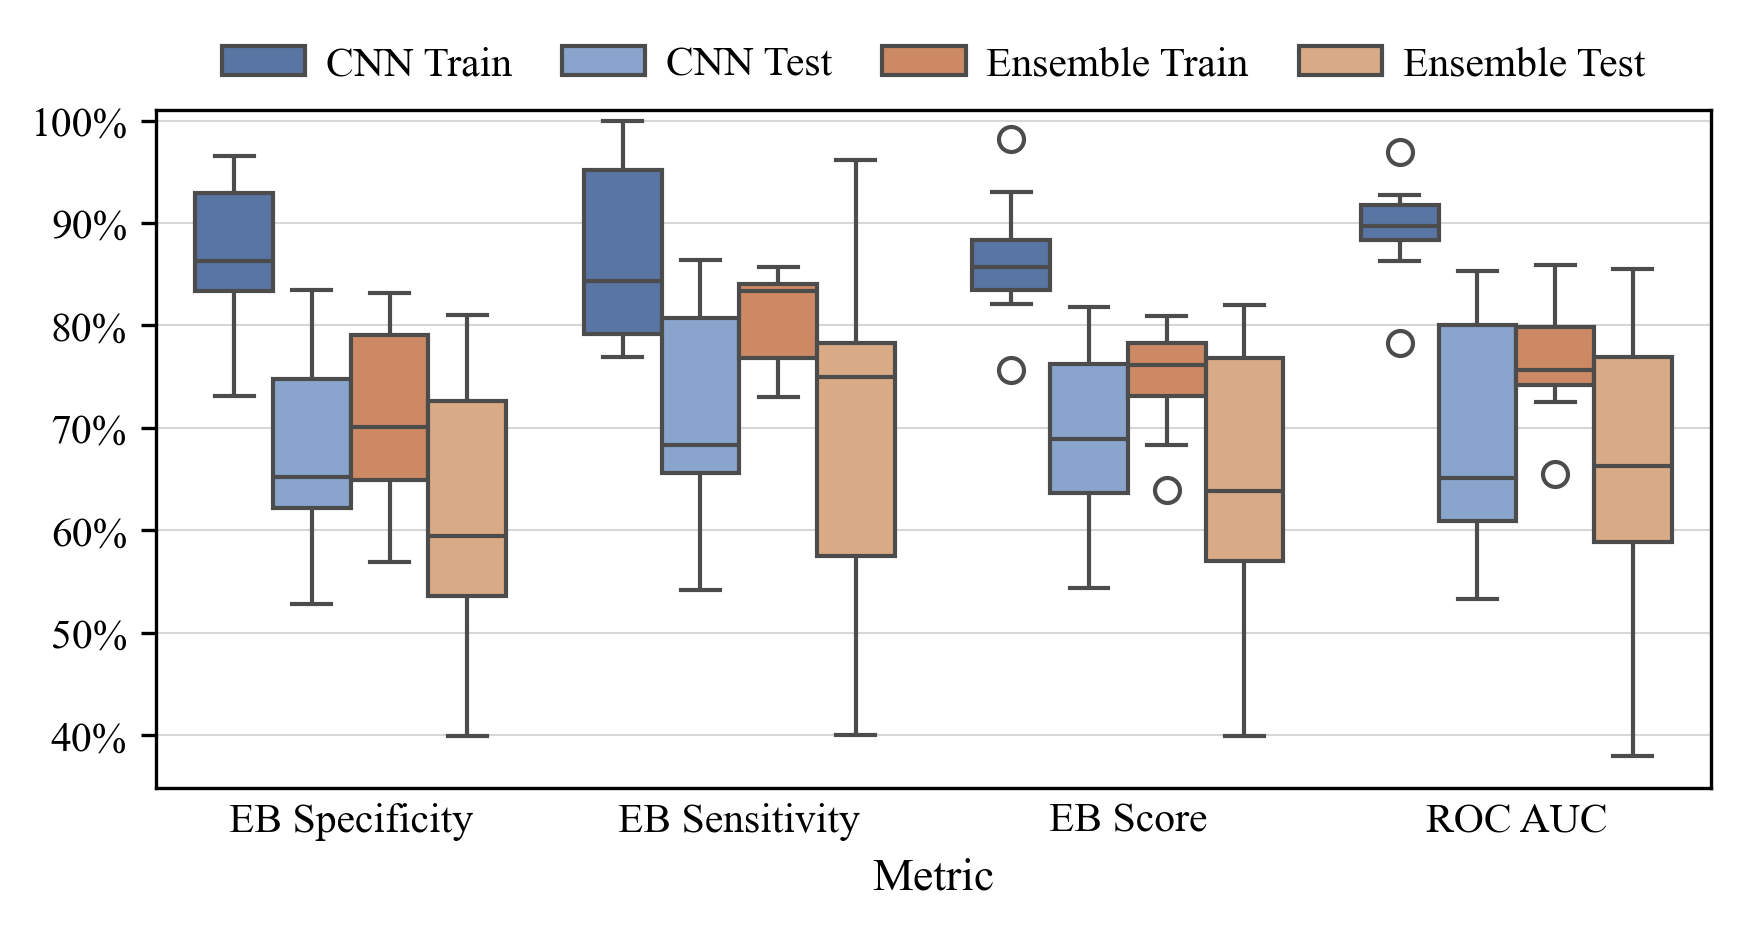

In [236]:
matplotlib_style.apply_style()
fig, ax = plt.subplots(figsize=matplotlib_style.latex_figsize(height_ratio=0.5))

# ---- Primary Plotting
palette = {
    "CNN Train": "#4C72B0",
    "CNN Test": "#7EA1D8",
    "Ensemble Train": "#DD8452",
    "Ensemble Test": "#E6A977",
}
sns.boxplot(data=f, x="metric", y="value", hue='Model & Partition', palette=palette, ax=ax)

# ---- Plot Formatting
# Y axis as percentages: 0%, 10%, ..., 100%
ax.yaxis.set_major_locator(plt.MultipleLocator(10))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))
ax.set_ylabel(None)
ax.set_ylim(None, 101)

# X axis
ax.set_xlabel("Metric")
ax.tick_params(axis='x', length=0)

ax.grid(axis='y', alpha=0.5)

ax.legend(
    title="",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15),
    ncol=4,
    frameon=False,
    columnspacing=1.2,   # space between legend columns
    handletextpad=0.5,   # space between color box and text
    # borderpad=0.2,       # padding inside legend frame
)
fig.tight_layout(pad=0)
plt.show(fig)

In [237]:
fig.savefig(out_path)